In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Imports OK')

/home/tan/anaconda3/envs/kangal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Imports OK


CSV shape: (21577, 168)  |  Malware: 11002  Benign: 10575
JSONL total: 14223  |  Malware: 8420  Benign: 5803

Seq length stats:
  min=10  max=368  median=25  mean=40.5  p95=118  p99=208
  >128: 578 (4.1%)  >256: 48 (0.3%)


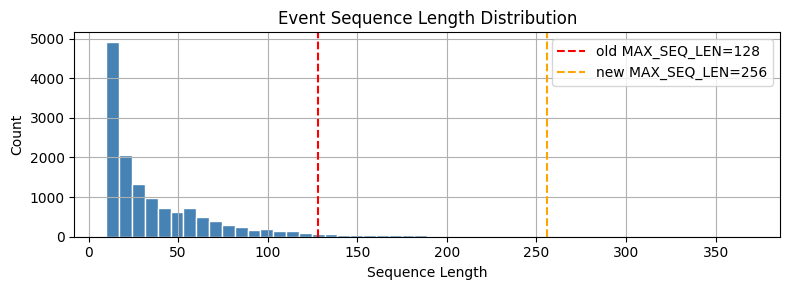

In [2]:
# ── Data Loading — CSV + JSONL ─────────────────────────────────────────────────

# 1. Tabular CSV (GBDT baseline için)
df_mal = pd.read_csv('kangal_malware.csv')
df_ben = pd.read_csv('krono_benign.csv', engine='python')   # FIX: C parser hatası
df_csv = pd.concat([df_mal, df_ben], ignore_index=True)
print(f'CSV shape: {df_csv.shape}  |  Malware: {len(df_mal)}  Benign: {len(df_ben)}')

# 2. Seq-log JSONL (Transformer için)
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return records

seq_mal = load_jsonl('kangal_malware_seqlogs.jsonl')
seq_ben = load_jsonl('krono_benign_seqlogs.jsonl')
seq_all = seq_mal + seq_ben
print(f'JSONL total: {len(seq_all)}  |  Malware: {len(seq_mal)}  Benign: {len(seq_ben)}')

# 3. Seq-log → DataFrame (Transformer verisi)
df_seq = pd.DataFrame([
    {
        'package_name'       : r['package_name'],
        'label'              : r['label'],
        'session_duration_ms': r['session_duration_ms'],
        'seq_log'            : r['seq_log'],
    }
    for r in seq_all
])
df_seq['label_bin'] = (df_seq['label'] == 'malware').astype(int)

seq_lens = df_seq['seq_log'].apply(len)
print(f'\nSeq length stats:')
print(f'  min={seq_lens.min()}  max={seq_lens.max()}  '
      f'median={seq_lens.median():.0f}  mean={seq_lens.mean():.1f}  '
      f'p95={seq_lens.quantile(0.95):.0f}  p99={seq_lens.quantile(0.99):.0f}')
print(f'  >128: {(seq_lens > 128).sum()} ({100*(seq_lens>128).mean():.1f}%)'
      f'  >256: {(seq_lens > 256).sum()} ({100*(seq_lens>256).mean():.1f}%)')

# Histogram
plt.figure(figsize=(8, 3))
seq_lens.hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red',    linestyle='--', label='old MAX_SEQ_LEN=128')
plt.axvline(256, color='orange', linestyle='--', label='new MAX_SEQ_LEN=256')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Event Sequence Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
# ── Vocabulary & Tokenization ─────────────────────────────────────────────────
# 87 tag — KANGAL_FEATURE_REFERENCE.md v4 Bölüm 2
TAGS = [
    # ── MALWARE-EXCLUSIVE (22) ──────────────────────────────────────────────
    'SCREEN_CAPTURE',      'INPUT_INJECT',        'KEYLOG',
    'PKG_INSTALL',         'PKG_DISABLE',
    'NOTIF_LISTEN',        'PHONE_CALL_SILENT',   'PHONE_STATE_LISTEN',
    'PERM_ADMIN_REQ',      'ACCOUNT_TOKEN_STEAL', 'KEYSTORE_EXFIL',
    'WEBVIEW_JS_BRIDGE',   'WEBVIEW_JS_EXEC',
    'MEM_EXEC_MMAP',       'DEX_LOAD_MEMORY',
    'FILE_ENCRYPT_BULK',
    'ANTI_HOOK_DETECT',    'ANTI_VM_PROPS',
    'BCAST_SMS_INTERCEPT', 'BCAST_SCREEN_WAKE',
    'ROOT_HIDE',           'ROOT_PERSIST_SYSTEM',
    # ── BENIGN-EXCLUSIVE (11) ───────────────────────────────────────────────
    'ADS_SDK_INIT',        'ANALYTICS_LOG',       'CRASH_REPORT',
    'IN_APP_PURCHASE',     'AUTH_OAUTH',           'AUTH_BIOMETRIC',
    'MAPS_API',            'CLOUD_STORAGE',        'SOCIAL_SHARE',
    'MEDIA_PLAY',          'NOTIF_POST_LEGIT',
    # ── NETWORK (7) ─────────────────────────────────────────────────────────
    'NET_HTTP_GET',        'NET_HTTP_POST',
    'NET_SOCKET_TCP',      'NET_SOCKET_UDP',
    'NET_DNS_LOOKUP',      'NET_SSL_BYPASS',       'NET_WEBSOCKET',
    # ── CRYPTO (7) ──────────────────────────────────────────────────────────
    'CRYPTO_AES',          'CRYPTO_RSA',
    'CRYPTO_HASH_MD5',     'CRYPTO_HASH_SHA',
    'CRYPTO_BASE64_ENC',   'CRYPTO_BASE64_DEC',    'CRYPTO_KEYGEN',
    # ── REFLECTION & LOADING (5) ────────────────────────────────────────────
    'REFLECT_INVOKE',      'REFLECT_CLASS_LOAD',   'REFLECT_FIELD_ACCESS',
    'DEX_LOAD_FILE',       'NATIVE_LIB_LOAD',
    # ── SURVEILLANCE (8) ────────────────────────────────────────────────────
    'SURV_DEVICE_ID',
    'SURV_LOCATION_GPS',   'SURV_LOCATION_NET',
    'SURV_CONTACT_READ',   'SURV_SMS_READ',        'SURV_CALL_LOG',
    'SURV_CAMERA',         'SURV_MIC_RECORD',
    # ── FILE OPERATIONS (4) ─────────────────────────────────────────────────
    'FILE_WRITE_INTERNAL', 'FILE_WRITE_EXTERNAL',
    'FILE_READ_SENSITIVE', 'FILE_DELETE',
    # ── EXECUTION (2) ───────────────────────────────────────────────────────
    'EXEC_SHELL_CMD',      'EXEC_ROOT_CMD',
    # ── PERSISTENCE (4) ─────────────────────────────────────────────────────
    'PERSIST_BOOT_RECV',   'PERSIST_ALARM_REP',
    'PERSIST_JOB_SCHED',   'PERSIST_FG_SERVICE',
    # ── ANTI-ANALYSIS (4) ───────────────────────────────────────────────────
    'ANTI_DEBUG',          'ANTI_EMULATOR',
    'ANTI_ROOT_CHECK',     'ANTI_SLEEP_LONG',
    # ── PACKAGE (1) ─────────────────────────────────────────────────────────
    'PKG_ENUMERATE',
    # ── IPC (3) ─────────────────────────────────────────────────────────────
    'IPC_BIND_SERVICE',    'IPC_SEND_BROADCAST',  'IPC_IMPLICIT_INTENT',
    # ── ACCESSIBILITY (3) ───────────────────────────────────────────────────
    'ACC_SERVICE_BIND',    'ACC_ACTION',           'ACC_WINDOW_ACCESS',
    # ── MEDIA & CONTENT (2) ─────────────────────────────────────────────────
    'MEDIA_PHOTO_ACCESS',  'MEDIA_VIDEO_ACCESS',
    # ── UI ABUSE (2) ────────────────────────────────────────────────────────
    'OVERLAY_WINDOW',      'CLIPBOARD_ACCESS',
    # ── C2 CHANNEL (2) ──────────────────────────────────────────────────────
    'PUSH_CHANNEL_REG',    'REMOTE_CONFIG_FETCH',
]
# Toplam: 87 tag

PAD_ID     = 0
TAG2ID     = {tag: i+1 for i, tag in enumerate(TAGS)}
ID2TAG     = {v: k for k, v in TAG2ID.items()}
VOCAB_SIZE = len(TAGS) + 1   # 88

# ── Aktif tag analizi ─────────────────────────────────────────────────────────
_data_tags: set = set()
for _r in seq_all:
    for _e in _r['seq_log']:
        _data_tags.add(_e['tag'])

ACTIVE_TAG_MASK = np.array(
    [1.0 if tag in _data_tags else 0.0 for tag in TAGS],
    dtype=np.float32
)
N_ACTIVE_TAGS = int(ACTIVE_TAG_MASK.sum())
print(f'Vocabulary size : {VOCAB_SIZE}  (87 tag + PAD)')
print(f'Tags in data    : {N_ACTIVE_TAGS} / {len(TAGS)}  '
      f'({len(TAGS) - N_ACTIVE_TAGS} tag hiç ateşlenmiyor)')

# Maksimum burst değeri
_MAX_BURST = max(
    (e['burst'] for r in seq_all for e in r['seq_log'] if 'burst' in e),
    default=30
)
_LOG_MAX_BURST = math.log1p(_MAX_BURST)
print(f'Max burst in data: {_MAX_BURST}  (log1p scale: {_LOG_MAX_BURST:.3f})')

# Malware / benign exclusive grupları
MAL_EXCLUSIVE = [
    'SCREEN_CAPTURE','INPUT_INJECT','KEYLOG','PKG_INSTALL','PKG_DISABLE',
    'NOTIF_LISTEN','PHONE_CALL_SILENT','PHONE_STATE_LISTEN','PERM_ADMIN_REQ',
    'ACCOUNT_TOKEN_STEAL','KEYSTORE_EXFIL','WEBVIEW_JS_BRIDGE','WEBVIEW_JS_EXEC',
    'MEM_EXEC_MMAP','DEX_LOAD_MEMORY','FILE_ENCRYPT_BULK',
    'ANTI_HOOK_DETECT','ANTI_VM_PROPS','BCAST_SMS_INTERCEPT','BCAST_SCREEN_WAKE',
    'ROOT_HIDE','ROOT_PERSIST_SYSTEM',
]
BEN_EXCLUSIVE = [
    'ADS_SDK_INIT','ANALYTICS_LOG','CRASH_REPORT','IN_APP_PURCHASE',
    'AUTH_OAUTH','AUTH_BIOMETRIC','MAPS_API','CLOUD_STORAGE',
    'SOCIAL_SHARE','MEDIA_PLAY','NOTIF_POST_LEGIT',
]

# ── N-gram Vocabulary ─────────────────────────────────────────────────────────
# Bigram/trigram frekansları TÜM sequence'lardan (train+val+test) hesaplanır.
# Label bilgisi kullanılmaz → label leakage yok.
# Amaç: Transformer'ın örtük olarak öğrendiği geçiş örüntülerini
#       açık sayısal özellik olarak modele sunmak.
from collections import Counter as _Counter

N_BIGRAMS  = 150
N_TRIGRAMS = 100
N_NGRAMS   = N_BIGRAMS + N_TRIGRAMS   # 250

_bigram_cnt  = _Counter()
_trigram_cnt = _Counter()
for _r in seq_all:
    _tags = [_e['tag'] for _e in _r['seq_log']]
    for _i in range(len(_tags) - 1):
        _bigram_cnt[(_tags[_i], _tags[_i+1])] += 1
    for _i in range(len(_tags) - 2):
        _trigram_cnt[(_tags[_i], _tags[_i+1], _tags[_i+2])] += 1

TOP_BIGRAMS  = [bg for bg, _ in _bigram_cnt.most_common(N_BIGRAMS)]
TOP_TRIGRAMS = [tg for tg, _ in _trigram_cnt.most_common(N_TRIGRAMS)]
BIGRAM2ID    = {bg: i           for i, bg in enumerate(TOP_BIGRAMS)}
TRIGRAM2ID   = {tg: i+N_BIGRAMS for i, tg in enumerate(TOP_TRIGRAMS)}

print(f'\nN-gram vocabulary: {N_BIGRAMS} bigrams + {N_TRIGRAMS} trigrams = {N_NGRAMS} features')
print(f'  En sık bigram-5  : {TOP_BIGRAMS[:5]}')
print(f'  En sık trigram-5 : {TOP_TRIGRAMS[:5]}')

def encode_seq(seq_log, session_duration_ms, max_len=256):
    """
    Returns:
        tag_ids    : np.int64   [max_len]   — 0=PAD
        time_vals  : np.float32 [max_len]   — ms/dur  (0–1)
        delta_vals : np.float32 [max_len]   — delta_ms/dur (0–1)
        burst_vals : np.float32 [max_len]   — log1p(burst)/log1p(max_burst) (0–1)
        attn_mask  : np.bool_   [max_len]   — True=PAD
        tag_freq   : np.float32 [len(TAGS)] — burst-weighted relative tag frequency
        ngram_feat : np.float32 [N_NGRAMS]  — normalized bigram+trigram counts
    """
    dur    = max(session_duration_ms, 1)
    events = seq_log[:max_len]

    tag_ids    = np.zeros(max_len,   dtype=np.int64)
    time_vals  = np.zeros(max_len,   dtype=np.float32)
    delta_vals = np.zeros(max_len,   dtype=np.float32)
    burst_vals = np.zeros(max_len,   dtype=np.float32)
    attn_mask  = np.ones(max_len,    dtype=bool)
    tag_freq   = np.zeros(len(TAGS), dtype=np.float32)
    ngram_feat = np.zeros(N_NGRAMS,  dtype=np.float32)

    prev_ms = 0
    raw_tags = []
    for i, ev in enumerate(events):
        tid           = TAG2ID.get(ev['tag'], PAD_ID)
        cur_ms        = ev['ms']
        burst         = ev.get('burst', 1)
        tag_ids[i]    = tid
        time_vals[i]  = min(cur_ms / dur, 1.0)
        delta_vals[i] = min((cur_ms - prev_ms) / dur, 1.0)
        burst_vals[i] = math.log1p(burst) / _LOG_MAX_BURST
        attn_mask[i]  = False
        if tid > 0:
            tag_freq[tid - 1] += burst
        raw_tags.append(ev['tag'])
        prev_ms = cur_ms

    # Bigram sayımı
    for i in range(len(raw_tags) - 1):
        bg = (raw_tags[i], raw_tags[i+1])
        if bg in BIGRAM2ID:
            ngram_feat[BIGRAM2ID[bg]] += 1.0

    # Trigram sayımı
    for i in range(len(raw_tags) - 2):
        tg = (raw_tags[i], raw_tags[i+1], raw_tags[i+2])
        if tg in TRIGRAM2ID:
            ngram_feat[TRIGRAM2ID[tg]] += 1.0

    # Normalize
    total = tag_freq.sum()
    if total > 0:
        tag_freq /= total

    ng_total = ngram_feat.sum()
    if ng_total > 0:
        ngram_feat /= ng_total

    return tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat

print('encode_seq OK (tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat)')

Vocabulary size : 88  (87 tag + PAD)
Tags in data    : 62 / 87  (25 tag hiç ateşlenmiyor)
Max burst in data: 29  (log1p scale: 3.401)

N-gram vocabulary: 150 bigrams + 100 trigrams = 250 features
  En sık bigram-5  : [('REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD'), ('REFLECT_FIELD_ACCESS', 'REFLECT_FIELD_ACCESS'), ('NET_HTTP_GET', 'NET_DNS_LOOKUP'), ('FILE_WRITE_INTERNAL', 'FILE_DELETE'), ('FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL')]
  En sık trigram-5 : [('REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD', 'REFLECT_CLASS_LOAD'), ('REFLECT_FIELD_ACCESS', 'REFLECT_FIELD_ACCESS', 'REFLECT_CLASS_LOAD'), ('NET_DNS_LOOKUP', 'NET_HTTP_GET', 'NET_DNS_LOOKUP'), ('FILE_WRITE_INTERNAL', 'FILE_WRITE_INTERNAL', 'FILE_DELETE'), ('NET_HTTP_GET', 'NET_DNS_LOOKUP', 'NET_HTTP_GET')]
encode_seq OK (tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat)


In [4]:
# ── PyTorch Dataset & DataLoader ──────────────────────────────────────────────
MAX_SEQ_LEN = 256

class SeqLogDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN):
        self.df      = df.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )
        return (
            torch.tensor(tag_ids,    dtype=torch.long),
            torch.tensor(time_vals,  dtype=torch.float),
            torch.tensor(delta_vals, dtype=torch.float),
            torch.tensor(burst_vals, dtype=torch.float),
            torch.tensor(attn_mask,  dtype=torch.bool),
            torch.tensor(tag_freq,   dtype=torch.float),
            torch.tensor(ngram_feat, dtype=torch.float),
            torch.tensor(row['label_bin'], dtype=torch.float),
        )

# ── Train / Val / Test split (stratified) ────────────────────────────────────
y_all = df_seq['label_bin'].values

idx_trainval, idx_test = train_test_split(
    np.arange(len(df_seq)), test_size=0.15, stratify=y_all, random_state=42
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.12, stratify=y_all[idx_trainval], random_state=42
)

print(f'Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}')
print(f'Train malware ratio: {y_all[idx_train].mean():.3f}')
print(f'Val   malware ratio: {y_all[idx_val].mean():.3f}')
print(f'Test  malware ratio: {y_all[idx_test].mean():.3f}')

BATCH_SIZE = 64

def dynamic_collate(batch):
    """Batch içindeki en uzun sequence'a göre pad et (global max değil).
    Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_f, ngram_f, labels
    """
    tag_ids, time_v, delta_v, burst_v, attn_m, tag_f, ngram_f, labels = zip(*batch)

    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)

    def pad_seq(t, pad_val=0):
        return t[:max_len]

    tag_ids_p  = torch.stack([pad_seq(t) for t in tag_ids])
    time_v_p   = torch.stack([pad_seq(t) for t in time_v])
    delta_v_p  = torch.stack([pad_seq(t) for t in delta_v])
    burst_v_p  = torch.stack([pad_seq(t) for t in burst_v])
    attn_m_p   = torch.stack([pad_seq(t, pad_val=True) for t in attn_m])
    tag_f_p    = torch.stack(list(tag_f))
    ngram_f_p  = torch.stack(list(ngram_f))
    labels_p   = torch.stack(list(labels))
    return tag_ids_p, time_v_p, delta_v_p, burst_v_p, attn_m_p, tag_f_p, ngram_f_p, labels_p

train_ds = SeqLogDataset(df_seq.iloc[idx_train])
val_ds   = SeqLogDataset(df_seq.iloc[idx_val])
test_ds  = SeqLogDataset(df_seq.iloc[idx_test])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
print('DataLoaders ready.  (dinamik padding aktif, ngram_feat eklendi)')
print(f'Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_freq, ngram_feat, labels  (8 item)')

Train: 10638  Val: 1451  Test: 2134
Train malware ratio: 0.592
Val   malware ratio: 0.592
Test  malware ratio: 0.592
DataLoaders ready.  (dinamik padding aktif, ngram_feat eklendi)
Batch items: tag_ids, time_v, delta_v, burst_v, attn_m, tag_freq, ngram_feat, labels  (8 item)


In [5]:
# ── Self-Supervised Pretraining — Dataset & Model ─────────────────────────────
#
# v3 → v5 strateji değişikliği:
#   v4: Masked Diffusion ile sentetik veri üretimi  → iyileşme görülmedi
#   v5: Self-supervised pretraining → supervised fine-tuning
#       Üç görev: MEM + NEP + TBP
#
# v9: encode_seq artık 7 değer döndürüyor (ngram_feat eklendi).
#     PretrainDataset sadece sequence özelliklerini kullanır → ngram_feat yok sayılır.

MASK_ID        = VOCAB_SIZE          # 88
PRETRAIN_VOCAB = VOCAB_SIZE + 1      # 89
N_TIME_BUCKETS = 10
MASK_PROB      = 0.15
MASK_REPLACE   = 0.80
MASK_RANDOM    = 0.10


class PretrainDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN, mask_prob=MASK_PROB):
        self.df        = df.reset_index(drop=True)
        self.max_len   = max_len
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # encode_seq 7 değer döndürür; ngram_feat pretrain için kullanılmaz
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, _, _ = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )

        # Zaman kovası: time_vals [0,1] → ondalık (0-9), PAD → -1
        time_buckets = np.full(self.max_len, -1, dtype=np.int64)
        non_pad = ~attn_mask
        if non_pad.any():
            buckets = np.floor(time_vals[non_pad] * N_TIME_BUCKETS).astype(int)
            time_buckets[non_pad] = np.clip(buckets, 0, N_TIME_BUCKETS - 1)

        # BERT-tarzı maskeleme (MEM için)
        tag_ids_orig   = tag_ids.copy()
        tag_ids_masked = tag_ids.copy()
        mem_mask       = np.zeros(self.max_len, dtype=bool)

        non_pad_idx = np.where(non_pad)[0]
        n_mask      = max(1, int(len(non_pad_idx) * self.mask_prob))
        selected    = np.random.choice(non_pad_idx, size=n_mask, replace=False)
        mem_mask[selected] = True

        for pos in selected:
            r = np.random.random()
            if r < MASK_REPLACE:
                tag_ids_masked[pos] = MASK_ID
            elif r < MASK_REPLACE + MASK_RANDOM:
                tag_ids_masked[pos] = np.random.randint(1, VOCAB_SIZE)

        return (
            torch.tensor(tag_ids_masked, dtype=torch.long),
            torch.tensor(tag_ids_orig,   dtype=torch.long),
            torch.tensor(mem_mask,       dtype=torch.bool),
            torch.tensor(time_vals,      dtype=torch.float),
            torch.tensor(delta_vals,     dtype=torch.float),
            torch.tensor(burst_vals,     dtype=torch.float),
            torch.tensor(attn_mask,      dtype=torch.bool),
            torch.tensor(time_buckets,   dtype=torch.long),
        )


class EventSequencePretrainer(nn.Module):
    """
    Self-supervised ön-eğitim modeli — üç görev: MEM + NEP + TBP.
    embed_dim=256, nhead=8, num_layers=3, ff_dim=512.
    """
    def __init__(
        self,
        vocab_size  = PRETRAIN_VOCAB,
        embed_dim   = 256,
        nhead       = 8,
        num_layers  = 3,
        ff_dim      = 512,
        dropout     = 0.10,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.mem_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.nep_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.tbp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, N_TIME_BUCKETS),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()

    def forward(self, tag_ids_masked, time_vals, delta_vals, burst_vals, attn_mask):
        tag_e   = self.tag_emb(tag_ids_masked)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x       = self.input_norm(tag_e + time_e + delta_e + burst_e)
        out     = self.encoder(x, src_key_padding_mask=attn_mask)
        return self.mem_head(out), self.nep_head(out), self.tbp_head(out)


pretrainer = EventSequencePretrainer().to(DEVICE)
n_params   = sum(p.numel() for p in pretrainer.parameters() if p.requires_grad)
print(f'EventSequencePretrainer — trainable params: {n_params:,}')
print(f'  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10')
print(f'  Görevler: MEM + NEP + TBP')
print(f'  MASK_ID={MASK_ID}  PRETRAIN_VOCAB={PRETRAIN_VOCAB}  N_TIME_BUCKETS={N_TIME_BUCKETS}')
print(f'  PretrainDataset: encode_seq 7 değer (ngram_feat yok sayılır)')

EventSequencePretrainer — trainable params: 1,916,986
  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10
  Görevler: MEM + NEP + TBP
  MASK_ID=88  PRETRAIN_VOCAB=89  N_TIME_BUCKETS=10
  PretrainDataset: encode_seq 7 değer (ngram_feat yok sayılır)


Pretraining: 12089 sequence  (10638 train + 1451 val,  test dokunulmadı)
PRETRAIN_EPOCHS=150  (v8 ile aynı)

 Epoch        LR     Total      MEM      NEP      TBP
----------------------------------------------------------
     1  3.00e-04    4.9342   2.5146   2.1775   0.4843
    10  2.97e-04    3.5093   1.9560   1.4977   0.1112
    20  2.87e-04    3.2857   1.8440   1.3960   0.0915
    30  2.72e-04    3.1385   1.7631   1.3342   0.0824
    40  2.52e-04    3.0361   1.7127   1.2881   0.0706
    50  2.28e-04    2.9529   1.6690   1.2496   0.0687
    60  2.00e-04    2.8743   1.6257   1.2179   0.0614
    70  1.70e-04    2.8171   1.5966   1.1918   0.0574
    80  1.40e-04    2.7520   1.5591   1.1664   0.0530
    90  1.10e-04    2.6998   1.5281   1.1469   0.0495
   100  8.25e-05    2.6629   1.5099   1.1295   0.0470
   110  5.80e-05    2.6172   1.4780   1.1165   0.0456
   120  3.77e-05    2.5916   1.4642   1.1055   0.0438
   130  2.25e-05    2.5721   1.4534   1.0975   0.0424
   140  1.32e-05    2.

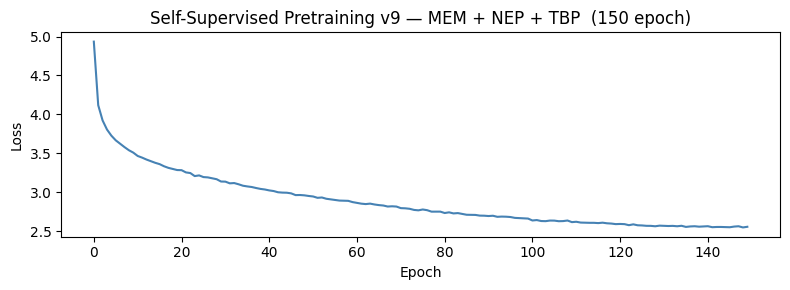

Pretrained encoder ağırlıkları MalwareTransformerV9 için hazır.


In [6]:
# ── Self-Supervised Pretraining — Eğitim Döngüsü ──────────────────────────────
#
# Sadece train+val sequence'ları kullanılır (LABEL YOK, test seti dokunulmaz).
# L_total = L_mem + L_nep + λ_tbp × L_tbp
#
# v8: PRETRAIN_EPOCHS=150 (v7:100, loss hâlâ düşüyordu)
# v9: v8 ile aynı pretrain — yeni ngram branch fine-tuning'de ekleniyor.

PRETRAIN_EPOCHS  = 150
PRETRAIN_LR      = 3e-4
PRETRAIN_BATCH   = 64
TBP_WEIGHT       = 0.5

df_pretrain  = df_seq.iloc[np.concatenate([idx_train, idx_val])].reset_index(drop=True)
pretrain_ds  = PretrainDataset(df_pretrain)

def pretrain_collate(batch):
    tag_m, tag_o, mem_mask, time_v, delta_v, burst_v, attn_m, tbuckets = zip(*batch)
    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)
    def pad(t, pv=0): return t[:max_len]
    def pad_bool(t, pv=True): return t[:max_len]
    return (
        torch.stack([pad(t)      for t in tag_m]),
        torch.stack([pad(t)      for t in tag_o]),
        torch.stack([pad_bool(t, False) for t in mem_mask]),
        torch.stack([pad(t)      for t in time_v]),
        torch.stack([pad(t)      for t in delta_v]),
        torch.stack([pad(t)      for t in burst_v]),
        torch.stack([pad_bool(t) for t in attn_m]),
        torch.stack([pad(t, -1)  for t in tbuckets]),
    )

pretrain_dl  = DataLoader(pretrain_ds, batch_size=PRETRAIN_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=pretrain_collate)
print(f'Pretraining: {len(pretrain_ds)} sequence  '
      f'({len(idx_train)} train + {len(idx_val)} val,  test dokunulmadı)')
print(f'PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}  (v8 ile aynı)')

pretrain_opt   = AdamW(pretrainer.parameters(), lr=PRETRAIN_LR, weight_decay=1e-2)
pretrain_sched = CosineAnnealingLR(pretrain_opt, T_max=PRETRAIN_EPOCHS, eta_min=1e-5)

mem_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
nep_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
tbp_crit = nn.CrossEntropyLoss(ignore_index=-1)

pretrain_history = []

print(f"\n{'Epoch':>6}  {'LR':>8}  {'Total':>8}  {'MEM':>7}  {'NEP':>7}  {'TBP':>7}")
print('-' * 58)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pretrainer.train()
    tot, mem_t, nep_t, tbp_t, nb = 0.0, 0.0, 0.0, 0.0, 0

    for batch in pretrain_dl:
        (tag_masked, tag_orig, mem_mask,
         time_v, delta_v, burst_v,
         attn_mask, time_buckets) = [b.to(DEVICE) for b in batch]

        mem_logits, nep_logits, tbp_logits = pretrainer(
            tag_masked, time_v, delta_v, burst_v, attn_mask
        )
        B, L, V = mem_logits.shape

        mem_targets = tag_orig.view(B * L).clone()
        mem_targets[~mem_mask.view(B * L)] = PAD_ID
        l_mem = mem_crit(mem_logits.view(B * L, V), mem_targets)

        nep_pred    = nep_logits[:, :-1, :].reshape(-1, V)
        nep_targets = tag_orig[:, 1:].reshape(-1)
        l_nep = nep_crit(nep_pred, nep_targets)

        l_tbp = tbp_crit(tbp_logits.view(B * L, N_TIME_BUCKETS),
                         time_buckets.view(B * L))

        loss = l_mem + l_nep + TBP_WEIGHT * l_tbp
        pretrain_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(pretrainer.parameters(), 1.0)
        pretrain_opt.step()

        tot   += loss.item()
        mem_t += l_mem.item()
        nep_t += l_nep.item()
        tbp_t += l_tbp.item()
        nb    += 1

    pretrain_sched.step()
    pretrain_history.append(tot / nb)

    if epoch % 10 == 0 or epoch == 1:
        lr = pretrain_sched.get_last_lr()[0]
        print(f'{epoch:>6}  {lr:>8.2e}  {tot/nb:>8.4f}  '
              f'{mem_t/nb:>7.4f}  {nep_t/nb:>7.4f}  {tbp_t/nb:>7.4f}')

print('\nÖn-eğitim tamamlandı.')

plt.figure(figsize=(8, 3))
plt.plot(pretrain_history, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Self-Supervised Pretraining v9 — MEM + NEP + TBP  (150 epoch)')
plt.tight_layout(); plt.show()

print('Pretrained encoder ağırlıkları MalwareTransformerV9 için hazır.')

In [7]:
# ── MalwareTransformerV9 — v8 + N-gram Branch ────────────────────────────────
#
# v8 → v9 değişikliği (tek değişiklik):
#
#   YENİ: N-gram Branch (ngram_proj)
#     Giriş  : ngram_feat [N_NGRAMS=250]  — normalize bigram+trigram sayımları
#     Çıkış  : 256-dim vektör
#     Mimari : Linear(250→256) → GELU → LayerNorm → Dropout
#              → Linear(256→256) → GELU → LayerNorm
#
#   Motivasyon:
#     Transformer attention, geçiş örüntülerini (örn. REFLECT_INVOKE→DEX_LOAD_MEMORY)
#     örtük olarak kodlar. Ancak bunu global dikkat matrisi üzerinden yapar.
#     N-gram branch, bu bilgiyi açık bir sayısal özellik olarak sunar:
#       - Sınır örnekleri için ek sinyal → val performansı artar
#       - Modelin attention mekanizmasına bağımlılığı azalır
#       - 250-dim küçük vektör → overfitting riski düşük
#
#   Füzyon: [cls | tf_mean | lstm_out | freq_out | ngram_out] = 5×256=1280
#   Diğer tüm parametreler v8 ile aynı:
#     dropout=0.30, lstm_dropout=0.25, noise_sigma=0.10
#     LSTM: last_hidden + mean_pool (residual)

class MalwareTransformerV9(nn.Module):
    """
    Hibrit: SSL-Pretrained Transformer + BiLSTM + Freq + N-gram Branch

    Akış:
      tag_ids, time_vals, delta_vals, burst_vals
          → Ortak Embedding (pretrained) + Diffusion Noise (σ=0.10)
          ├── Transformer Branch → CLS + mean-pool   (2×256)
          └── BiLSTM Branch     → last + mean-pool residual (256)
      tag_freq  → Freq Branch   (256)
      ngram_feat → N-gram Branch (256)
      Füzyon → [cls|tf_mean|lstm_out|freq_out|ngram_out] = 5×256=1280 → 256 → 1
    """
    def __init__(
        self,
        vocab_size    = PRETRAIN_VOCAB,
        embed_dim     = 256,
        nhead         = 8,
        num_layers    = 3,
        ff_dim        = 512,
        dropout       = 0.30,
        token_drop_p  = 0.10,
        lstm_hidden   = 128,
        lstm_layers   = 2,
        lstm_dropout  = 0.25,
        noise_sigma   = 0.10,
        n_tags        = len(TAGS),
        n_ngrams      = N_NGRAMS,
    ):
        super().__init__()
        self.embed_dim    = embed_dim
        self.token_drop_p = token_drop_p
        self.noise_sigma  = noise_sigma

        # ── Ortak Embedding (pretrained) ──────────────────────────────────────
        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        # ── Transformer Branch (pretrained) ──────────────────────────────────
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # ── BiLSTM Branch ────────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            dropout       = lstm_dropout if lstm_layers > 1 else 0.0,
            bidirectional = True,
            batch_first   = True,
        )
        self.lstm_norm = nn.LayerNorm(lstm_hidden * 2)

        # ── Frequency Branch ─────────────────────────────────────────────────
        self.register_buffer('active_mask', torch.tensor(ACTIVE_TAG_MASK))
        self.freq_proj = nn.Sequential(
            nn.Linear(n_tags, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )

        # ── N-gram Branch (YENİ) ─────────────────────────────────────────────
        # normalize bigram+trigram sayımları → 256-dim
        self.ngram_proj = nn.Sequential(
            nn.Linear(n_ngrams, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )

        # ── Füzyon Kafası ─────────────────────────────────────────────────────
        fuse_dim = embed_dim * 5   # [cls | tf_mean | lstm_out | freq_out | ngram_out]
        self.head = nn.Sequential(
            nn.LayerNorm(fuse_dim),
            nn.Linear(fuse_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)

    def load_pretrained_encoder(self, pretrainer):
        """EventSequencePretrainer omurgasını aktarır (Transformer branch)."""
        self.tag_emb.load_state_dict(pretrainer.tag_emb.state_dict())
        self.time_proj.load_state_dict(pretrainer.time_proj.state_dict())
        self.delta_proj.load_state_dict(pretrainer.delta_proj.state_dict())
        self.burst_proj.load_state_dict(pretrainer.burst_proj.state_dict())
        self.encoder.load_state_dict(pretrainer.encoder.state_dict())
        print('Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.')
        print('BiLSTM + N-gram branch sıfırdan eğitilecek.')

    def _apply_token_dropout(self, tag_ids, pad_mask):
        if not self.training or self.token_drop_p <= 0:
            return tag_ids, pad_mask
        non_pad   = ~pad_mask
        drop_mask = (torch.rand_like(tag_ids, dtype=torch.float) < self.token_drop_p) & non_pad
        new_tag_ids = tag_ids.clone()
        new_tag_ids[drop_mask] = PAD_ID
        return new_tag_ids, pad_mask | drop_mask

    def forward(self, tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                tag_freq, ngram_feat):
        B, L = tag_ids.shape
        tag_ids, pad_mask = self._apply_token_dropout(tag_ids, pad_mask)

        # ── Ortak Embedding ───────────────────────────────────────────────────
        tag_e   = self.tag_emb(tag_ids)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x = self.input_norm(tag_e + time_e + delta_e + burst_e)

        # ── Diffusion Noise (sadece eğitimde) ─────────────────────────────────
        if self.training and self.noise_sigma > 0:
            x = x + torch.randn_like(x) * self.noise_sigma

        # ── Transformer Branch ────────────────────────────────────────────────
        cls       = self.cls_token.expand(B, -1, -1)
        x_tf      = torch.cat([cls, x], dim=1)
        cls_mask  = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)
        out_tf    = self.encoder(x_tf, src_key_padding_mask=full_mask)
        cls_out   = out_tf[:, 0, :]
        seq_out   = out_tf[:, 1:, :]
        non_pad   = (~pad_mask).float().unsqueeze(-1)
        tf_mean   = (seq_out * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)

        # ── BiLSTM Branch — last hidden + mean pool (residual) ─────────────
        real_lens = (~pad_mask).sum(dim=1).cpu().clamp(min=1)
        packed    = pack_padded_sequence(x, real_lens, batch_first=True,
                                         enforce_sorted=False)
        lstm_out_packed, (h_n, _) = self.bilstm(packed)
        lstm_last = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        lstm_seq, _ = pad_packed_sequence(lstm_out_packed, batch_first=True)
        seq_len_out = lstm_seq.size(1)
        if seq_len_out < L:
            pad_zeros = torch.zeros(B, L - seq_len_out, lstm_seq.size(2),
                                    device=x.device)
            lstm_seq = torch.cat([lstm_seq, pad_zeros], dim=1)
        else:
            lstm_seq = lstm_seq[:, :L, :]
        lstm_mean = (lstm_seq * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)
        lstm_out  = self.lstm_norm(lstm_last + lstm_mean)

        # ── Frequency Branch ──────────────────────────────────────────────────
        masked_freq = tag_freq * self.active_mask
        freq_out    = self.freq_proj(masked_freq)

        # ── N-gram Branch ─────────────────────────────────────────────────────
        ngram_out = self.ngram_proj(ngram_feat)

        # ── Füzyon ───────────────────────────────────────────────────────────
        fused = torch.cat([cls_out, tf_mean, lstm_out, freq_out, ngram_out], dim=-1)
        return self.head(fused).squeeze(-1)


model = MalwareTransformerV9().to(DEVICE)
model.load_pretrained_encoder(pretrainer)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MalwareTransformerV9 — trainable params: {n_params:,}')
print(f'  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.30')
print(f'  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25')
print(f'  LSTM çıktı: last_hidden + mean_pool (residual)')
print(f'  Diffusion noise: σ=0.10')
print(f'  N-gram branch: {N_NGRAMS} ({N_BIGRAMS} bigram + {N_TRIGRAMS} trigram) → 256')
print(f'  Füzyon: 5×256=1280 → 256 → 1  (v8:4×256=1024)')

Pretrained encoder ağırlıkları MalwareTransformerV9 aktarıldı.
BiLSTM + N-gram branch sıfırdan eğitilecek.
MalwareTransformerV9 — trainable params: 3,046,913
  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.30
  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25
  LSTM çıktı: last_hidden + mean_pool (residual)
  Diffusion noise: σ=0.10
  N-gram branch: 250 (150 bigram + 100 trigram) → 256
  Füzyon: 5×256=1280 → 256 → 1  (v8:4×256=1024)


Train — malware: 6298  benign: 4340  pos_weight: 0.689
Discriminatif LR — encoder: 3e-05  bilstm: 1.5e-04  head+freq+ngram: 3e-04
Gradual unfreeze: Transformer encoder ilk 8 epoch dondurulur

 Epoch     LR_enc   TrainLoss   ValLoss   TrainAUC   ValAUC    ValF1     Gap   Frozen
------------------------------------------------------------------------------------------------
  [Epoch 1-8] Transformer encoder donduruldu — BiLSTM+head+ngram açık
     1   8.40e-06      0.5700    0.3673     0.7191   0.8793   0.7819  -0.160      YES
     5   3.00e-05      0.4365    0.2845     0.9196   0.9400   0.8532  -0.020      YES
  [Epoch 9] Encoder açıldı — enc=3e-05  lstm=1.5e-04  head=3e-04
    10   2.98e-05      0.4005    0.2563     0.9592   0.9569   0.8790  +0.002       no
    15   2.92e-05      0.3840    0.2453     0.9722   0.9609   0.8921  +0.011       no
    20   2.83e-05      0.3705    0.2410     0.9819   0.9580   0.8926  +0.024       no
    25   2.69e-05      0.3587    0.2421     0.9884   0.9552 

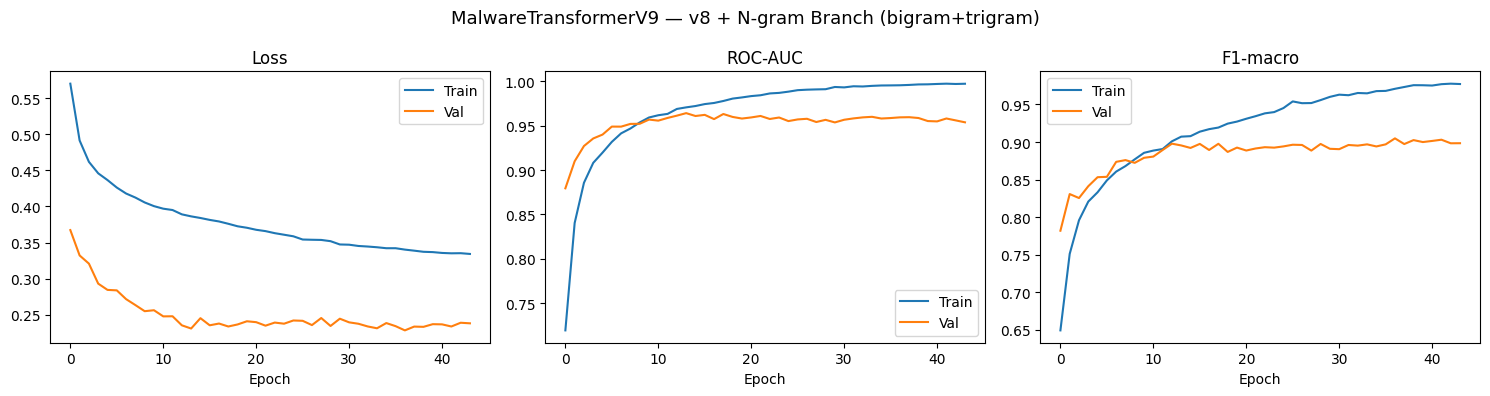

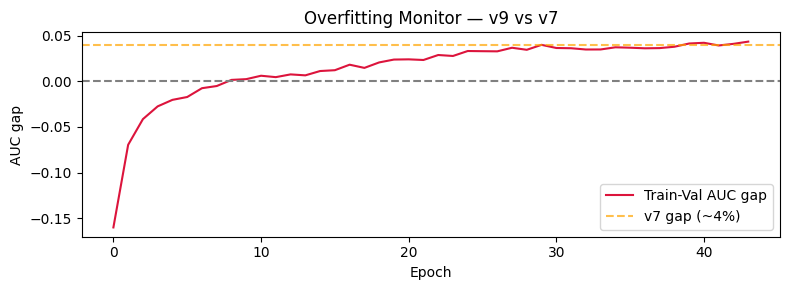

In [8]:
# ── Supervised Fine-tuning v9 ─────────────────────────────────────────────────
#
# v8 ile aynı fine-tuning parametreleri.
# Tek fark: run_epoch 8-item batch alıyor ve ngram_feat modele geçiliyor.
#
# Parametre grupları 4 gruba genişledi:
#   encoder (pretrained) → ENCODER_LR=3e-5
#   bilstm               → LSTM_LR=1.5e-4
#   head + freq_proj     → HEAD_LR=3e-4
#   ngram_proj (yeni)    → HEAD_LR=3e-4  (sıfırdan, yüksek LR uygun)

EPOCHS        = 100
WEIGHT_DECAY  = 2e-2
PATIENCE      = 30
WARMUP_EPOCHS = 5
LABEL_SMOOTH  = 0.12
ENCODER_LR    = 3e-5
LSTM_LR       = 1.5e-4
HEAD_LR       = 3e-4
FREEZE_EPOCHS = 8

n_mal_train = int(y_all[idx_train].sum())
n_ben_train = len(idx_train) - n_mal_train
pos_w = torch.tensor(n_ben_train / n_mal_train, dtype=torch.float).to(DEVICE)
print(f'Train — malware: {n_mal_train}  benign: {n_ben_train}  pos_weight: {pos_w.item():.3f}')
print(f'Discriminatif LR — encoder: {ENCODER_LR:.0e}  bilstm: {LSTM_LR:.1e}  head+freq+ngram: {HEAD_LR:.0e}')
print(f'Gradual unfreeze: Transformer encoder ilk {FREEZE_EPOCHS} epoch dondurulur')

def set_encoder_grad(requires_grad: bool):
    for p in model.tag_emb.parameters():    p.requires_grad_(requires_grad)
    for p in model.time_proj.parameters():  p.requires_grad_(requires_grad)
    for p in model.delta_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.burst_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.encoder.parameters():    p.requires_grad_(requires_grad)
    model.cls_token.requires_grad_(requires_grad)
    for p in model.input_norm.parameters(): p.requires_grad_(requires_grad)

encoder_params = (
    list(model.tag_emb.parameters()) +
    list(model.time_proj.parameters()) +
    list(model.delta_proj.parameters()) +
    list(model.burst_proj.parameters()) +
    list(model.encoder.parameters()) +
    [model.cls_token] +
    list(model.input_norm.parameters())
)
lstm_params = (
    list(model.bilstm.parameters()) +
    list(model.lstm_norm.parameters())
)
head_params = (
    list(model.freq_proj.parameters()) +
    list(model.ngram_proj.parameters()) +
    list(model.head.parameters())
)

set_encoder_grad(False)

optimizer = AdamW(
    [{'params': encoder_params, 'lr': ENCODER_LR},
     {'params': lstm_params,    'lr': LSTM_LR},
     {'params': head_params,    'lr': HEAD_LR}],
    weight_decay=WEIGHT_DECAY,
)

from torch.optim.lr_scheduler import LinearLR, SequentialLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP_EPOCHS])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

def smooth_labels(labels, eps=LABEL_SMOOTH):
    return labels * (1 - eps) + (1 - labels) * eps

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for tag_ids, time_vals, delta_vals, burst_vals, pad_mask, tag_freq, ngram_feat, labels in loader:
            tag_ids    = tag_ids.to(DEVICE)
            time_vals  = time_vals.to(DEVICE)
            delta_vals = delta_vals.to(DEVICE)
            burst_vals = burst_vals.to(DEVICE)
            pad_mask   = pad_mask.to(DEVICE)
            tag_freq   = tag_freq.to(DEVICE)
            ngram_feat = ngram_feat.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits  = model(tag_ids, time_vals, delta_vals, burst_vals,
                            pad_mask, tag_freq, ngram_feat)
            targets = smooth_labels(labels) if train else labels
            loss    = criterion(logits, targets)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n     = len(all_labels)
    loss  = total_loss / n
    auc   = roc_auc_score(all_labels, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    f1    = f1_score(all_labels, preds, average='macro')
    return loss, auc, f1, np.array(all_probs), np.array(all_labels)

# ── Fine-tuning ────────────────────────────────────────────────────────────────
best_val_auc   = 0.0
patience_count = 0
best_state     = None
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'train_f1':[],'val_f1':[]}

print(f"\n{'Epoch':>6}  {'LR_enc':>9}  {'TrainLoss':>10}  {'ValLoss':>8}  "
      f"{'TrainAUC':>9}  {'ValAUC':>7}  {'ValF1':>7}  {'Gap':>6}  {'Frozen':>7}")
print('-' * 96)

for epoch in range(1, EPOCHS + 1):
    if epoch == 1:
        print(f'  [Epoch 1-{FREEZE_EPOCHS}] Transformer encoder donduruldu — BiLSTM+head+ngram açık')
    elif epoch == FREEZE_EPOCHS + 1:
        set_encoder_grad(True)
        print(f'  [Epoch {epoch}] Encoder açıldı — enc={ENCODER_LR:.0e}  lstm={LSTM_LR:.1e}  head={HEAD_LR:.0e}')

    frozen_str = 'YES' if epoch <= FREEZE_EPOCHS else 'no'

    tr_loss, tr_auc, tr_f1, _, _ = run_epoch(train_dl, train=True)
    vl_loss, vl_auc, vl_f1, _, _ = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if epoch % 5 == 0 or epoch == 1:
        cur_lr = optimizer.param_groups[0]['lr']
        gap    = tr_auc - vl_auc
        print(f'{epoch:>6}  {cur_lr:>9.2e}  {tr_loss:>10.4f}  {vl_loss:>8.4f}  '
              f'{tr_auc:>9.4f}  {vl_auc:>7.4f}  {vl_f1:>7.4f}  {gap:>+6.3f}  {frozen_str:>7}')

    if vl_auc > best_val_auc:
        best_val_auc   = vl_auc
        patience_count = 0
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val AUC: {best_val_auc:.4f})')
            break

print(f'\nBest val AUC: {best_val_auc:.4f}')

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)
    print('Best validation checkpoint geri yuklendi; threshold/test bu agirliklarla hesaplanacak.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], 'loss', 'Loss'),
    (axes[1], 'auc',  'ROC-AUC'),
    (axes[2], 'f1',   'F1-macro'),
]:
    ax.plot(history[f'train_{key}'], label='Train')
    ax.plot(history[f'val_{key}'],   label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('MalwareTransformerV9 — v8 + N-gram Branch (bigram+trigram)', fontsize=13)
plt.tight_layout(); plt.show()

gaps = [tr - vl for tr, vl in zip(history['train_auc'], history['val_auc'])]
plt.figure(figsize=(8, 3))
plt.plot(gaps, color='crimson', label='Train-Val AUC gap')
plt.axhline(0.040, linestyle='--', color='orange', alpha=0.7, label='v7 gap (~4%)')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Epoch'); plt.ylabel('AUC gap')
plt.title('Overfitting Monitor — v9 vs v7')
plt.legend(); plt.tight_layout(); plt.show()


In [9]:
# ── Threshold Optimization (Validation Set) ───────────────────────────────────
# Test setine sızmayı önlemek için threshold val set üzerinde seçilir.

model.load_state_dict(best_state)
model.to(DEVICE)

_, _, _, val_probs, val_labels = run_epoch(val_dl, train=False)

def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.20, 0.80, 0.01):
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, average='macro')
        if score > best_f1:
            best_f1, best_t = score, t
    return best_t, best_f1

THRESHOLD, val_f1_opt = find_best_threshold(val_labels, val_probs)
print(f'Optimal threshold: {THRESHOLD:.2f}  (val F1-macro = {val_f1_opt:.4f})')

Optimal threshold: 0.45  (val F1-macro = 0.9019)


=== MalwareTransformerV9 (threshold=0.45) ===
              precision    recall  f1-score   support

      benign     0.8584    0.8634    0.8609       871
     malware     0.9054    0.9018    0.9036      1263

    accuracy                         0.8861      2134
   macro avg     0.8819    0.8826    0.8823      2134
weighted avg     0.8862    0.8861    0.8862      2134

ROC-AUC: 0.9579  |  Avg-Prec: 0.9737


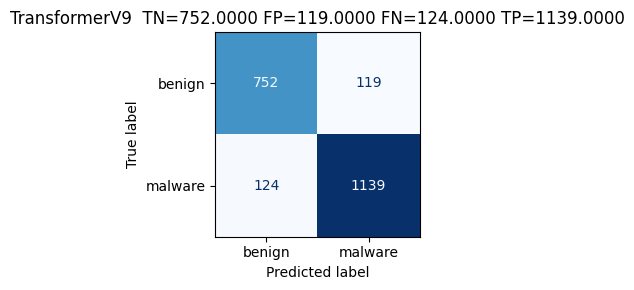

In [10]:
# ── Test Set Evaluation — Transformer ────────────────────────────────────────
_, _, _, test_probs, test_labels = run_epoch(test_dl, train=False)
test_preds = (test_probs >= THRESHOLD).astype(int)

print(f'=== MalwareTransformerV9 (threshold={THRESHOLD:.2f}) ===')
print(classification_report(test_labels.astype(int), test_preds,
                             target_names=['benign', 'malware'],digits=4))
txf_auc  = roc_auc_score(test_labels, test_probs)
txf_ap   = average_precision_score(test_labels, test_probs)
txf_f1   = f1_score(test_labels.astype(int), test_preds, average='macro')
txf_prec = precision_score(test_labels.astype(int), test_preds, pos_label=1)
txf_rec  = recall_score(test_labels.astype(int), test_preds, pos_label=1)
print(f'ROC-AUC: {txf_auc:.4f}  |  Avg-Prec: {txf_ap:.4f}')

# Confusion matrix
cm = confusion_matrix(test_labels.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'malware']).plot(ax=ax, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'TransformerV9  TN={tn:.4f} FP={fp:.4f} FN={fn:.4f} TP={tp:.4f}')
plt.tight_layout()
plt.show()

In [11]:

# ── V10 Training Policy — Simpler, Calibratable Baseline ─────────────────────
#
# v10 önceki sürümde Focal Loss + Aux MEM + Embedding Mixup'u aynı anda ekliyordu.
# Çıktılarda bu kombinasyon v9'a göre F1'i artırmadı ve olasılık kalibrasyonunu
# zorlaştırdı. Bu hücre v10'u daha kontrollü bir 5-fold ensemble deneyine çeker:
#
#   1. BCEWithLogitsLoss + fold'a özel pos_weight
#   2. Daha düşük label smoothing (ε=0.05)
#   3. Daha hafif regularization: dropout/token-drop/noise aşağı çekildi
#   4. Mixup, Aux MEM ve Focal Loss kaldırıldı; çelişkili sinyal/dead code yok
#   5. Calibration/threshold sadece validation OOF tahminleriyle yapılacak

V10_LABEL_SMOOTH = 0.05
V10_DROPOUT      = 0.25
V10_TOKEN_DROP_P = 0.05
V10_NOISE_SIGMA  = 0.05
V10_WEIGHT_DECAY = 1e-2
V10_HEAD_LR      = 2e-4
V10_LSTM_LR      = 1e-4
V10_ENCODER_LR   = 2e-5
V10_FREEZE_EPOCHS = 5


def smooth_binary_labels(labels, eps=V10_LABEL_SMOOTH):
    if eps <= 0:
        return labels
    return labels * (1 - eps) + (1 - labels) * eps


def probs_to_logits(probs, eps=1e-7):
    probs = np.clip(np.asarray(probs), eps, 1 - eps)
    return np.log(probs / (1 - probs))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi if hi < 1.0 else y_prob <= hi)
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)

print('V10 policy ready: BCE + fold pos_weight + light smoothing, no focal/mixup/aux-MEM')
print(f'  smoothing={V10_LABEL_SMOOTH}  dropout={V10_DROPOUT}  token_drop={V10_TOKEN_DROP_P}  noise={V10_NOISE_SIGMA}')
print(f'  LR enc={V10_ENCODER_LR:.0e}  lstm={V10_LSTM_LR:.0e}  head={V10_HEAD_LR:.0e}  wd={V10_WEIGHT_DECAY:.0e}')


V10 policy ready: BCE + fold pos_weight + light smoothing, no focal/mixup/aux-MEM
  smoothing=0.05  dropout=0.25  token_drop=0.05  noise=0.05
  LR enc=2e-05  lstm=1e-04  head=2e-04  wd=1e-02


In [12]:

# ── MalwareTransformerV10 — Calibratable V9 Variant ──────────────────────────
#
# V10 artık V9 mimarisinin daha hafif regularize edilmiş, 5-fold ensemble'a uygun
# varyantıdır. Önceki Aux MEM head ve embedding mixup kaldırıldı; çünkü global
# tag_freq/ngram_feat ile mixup label'ları tutarsız sinyal üretiyordu.

class MalwareTransformerV10(MalwareTransformerV9):
    def __init__(self, *args, **kwargs):
        kwargs.setdefault('dropout', V10_DROPOUT)
        kwargs.setdefault('token_drop_p', V10_TOKEN_DROP_P)
        kwargs.setdefault('noise_sigma', V10_NOISE_SIGMA)
        super().__init__(*args, **kwargs)

    def load_pretrained_encoder(self, pretrainer):
        self.tag_emb.load_state_dict(pretrainer.tag_emb.state_dict())
        self.time_proj.load_state_dict(pretrainer.time_proj.state_dict())
        self.delta_proj.load_state_dict(pretrainer.delta_proj.state_dict())
        self.burst_proj.load_state_dict(pretrainer.burst_proj.state_dict())
        self.encoder.load_state_dict(pretrainer.encoder.state_dict())
        print('Pretrained encoder agirliklari MalwareTransformerV10 aktarildi.')
        print('BiLSTM + freq/ngram + classification head fold icinde egitilecek.')


# Quick sanity check
model_v10 = MalwareTransformerV10().to(DEVICE)
model_v10.load_pretrained_encoder(pretrainer)
n_p = sum(p.numel() for p in model_v10.parameters() if p.requires_grad)
print(f'MalwareTransformerV10 — trainable params: {n_p:,}')
print('  V9 backbone + lighter regularization; aux/mixup/focal removed')


Pretrained encoder agirliklari MalwareTransformerV10 aktarildi.
BiLSTM + freq/ngram + classification head fold icinde egitilecek.
MalwareTransformerV10 — trainable params: 3,046,913
  V9 backbone + lighter regularization; aux/mixup/focal removed


In [13]:

# ── 5-Fold Stratified CV — V10 Training ──────────────────────────────────────
#
# CV scope: idx_trainval (train+val). Test set sadece final inference icin kullanilir.
# Her fold:
#   - train fold ile egitilir
#   - validation fold ile checkpoint/threshold raporlanir
#   - OOF validation prob'lari calibration ve final threshold icin saklanir
#   - test prob'lari ensemble icin saklanir

FOLD_EPOCHS   = 60
FOLD_PATIENCE = 15
N_FOLDS       = 5


def make_optimizer_v10(m):
    enc_p = (
        list(m.tag_emb.parameters()) + list(m.time_proj.parameters()) +
        list(m.delta_proj.parameters()) + list(m.burst_proj.parameters()) +
        list(m.encoder.parameters()) + [m.cls_token] +
        list(m.input_norm.parameters())
    )
    lstm_p = list(m.bilstm.parameters()) + list(m.lstm_norm.parameters())
    head_p = list(m.freq_proj.parameters()) + list(m.ngram_proj.parameters()) + list(m.head.parameters())
    return AdamW(
        [{'params': enc_p,  'lr': V10_ENCODER_LR},
         {'params': lstm_p, 'lr': V10_LSTM_LR},
         {'params': head_p, 'lr': V10_HEAD_LR}],
        weight_decay=V10_WEIGHT_DECAY,
    )


def set_enc_grad_v10(m, req):
    for mod in [m.tag_emb, m.time_proj, m.delta_proj,
                m.burst_proj, m.encoder, m.input_norm]:
        for p in mod.parameters():
            p.requires_grad_(req)
    m.cls_token.requires_grad_(req)


def make_fold_criterion(train_indices):
    y_fold = y_all[train_indices]
    n_pos = int(y_fold.sum())
    n_neg = len(y_fold) - n_pos
    pos_w = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32, device=DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pos_w), pos_w.item()


def run_epoch_v10(m, loader, criterion=None, opt=None, train=True):
    m.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []

    with torch.set_grad_enabled(train):
        for batch in loader:
            (tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
             tag_freq, ngram_feat, labels) = [b.to(DEVICE) for b in batch]

            logits = m(tag_ids, time_vals, delta_vals, burst_vals,
                       pad_mask, tag_freq, ngram_feat)

            if criterion is not None:
                targets = smooth_binary_labels(labels) if train else labels
                loss = criterion(logits, targets)
            else:
                loss = torch.zeros((), device=DEVICE)

            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()

            total_loss += loss.item() * len(labels)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    auc  = roc_auc_score(all_labels, all_probs)
    preds = (all_probs >= 0.5).astype(int)
    f1   = f1_score(all_labels, preds, average='macro')
    loss = total_loss / max(len(all_labels), 1)
    return loss, auc, f1, all_probs, all_labels


# ── 5-Fold Loop ───────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
X_cv = idx_trainval
y_cv = y_all[idx_trainval]

fold_results     = []
fold_test_probs  = []
oof_val_probs    = np.zeros(len(X_cv), dtype=np.float32)
oof_val_labels   = y_cv.astype(np.float32).copy()
oof_val_seen     = np.zeros(len(X_cv), dtype=bool)

print(f'5-Fold CV — V10  |  FOLD_EPOCHS={FOLD_EPOCHS}  PATIENCE={FOLD_PATIENCE}')
print('  Loss=BCEWithLogits(pos_weight fold-specific), threshold/calibration=OOF validation only')
print('=' * 78)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n-- Fold {fold}/{N_FOLDS} --------------------------------')

    fold_tr_idx = X_cv[tr_idx]
    fold_vl_idx = X_cv[vl_idx]

    fold_tr_dl = DataLoader(
        SeqLogDataset(df_seq.iloc[fold_tr_idx]),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True, collate_fn=dynamic_collate,
    )
    fold_vl_dl = DataLoader(
        SeqLogDataset(df_seq.iloc[fold_vl_idx]),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True, collate_fn=dynamic_collate,
    )

    criterion, fold_pos_w = make_fold_criterion(fold_tr_idx)

    m = MalwareTransformerV10().to(DEVICE)
    m.load_pretrained_encoder(pretrainer)
    set_enc_grad_v10(m, False)

    opt = make_optimizer_v10(m)
    sched = SequentialLR(
        opt,
        schedulers=[LinearLR(opt, start_factor=0.1, end_factor=1.0,
                             total_iters=WARMUP_EPOCHS),
                    CosineAnnealingLR(opt, T_max=FOLD_EPOCHS - WARMUP_EPOCHS,
                                      eta_min=1e-6)],
        milestones=[WARMUP_EPOCHS],
    )

    best_auc, pat_cnt, best_st = 0.0, 0, None
    print(f'  pos_weight={fold_pos_w:.3f}; encoder frozen first {V10_FREEZE_EPOCHS} epochs')

    for epoch in range(1, FOLD_EPOCHS + 1):
        if epoch == V10_FREEZE_EPOCHS + 1:
            set_enc_grad_v10(m, True)

        tr_loss, tr_auc, _, _, _ = run_epoch_v10(
            m, fold_tr_dl, criterion=criterion, opt=opt, train=True
        )
        vl_loss, vl_auc, vl_f1_05, _, _ = run_epoch_v10(
            m, fold_vl_dl, criterion=criterion, train=False
        )
        sched.step()

        if vl_auc > best_auc:
            best_auc = vl_auc
            pat_cnt = 0
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            pat_cnt += 1
            if pat_cnt >= FOLD_PATIENCE:
                print(f'  Early stop @ epoch {epoch}  (best val AUC: {best_auc:.4f})')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'  ep{epoch:>3}  tr_loss={tr_loss:.4f}  vl_loss={vl_loss:.4f}  '
                  f'tr_auc={tr_auc:.4f}  vl_auc={vl_auc:.4f}  vl_f1@0.5={vl_f1_05:.4f}')

    assert best_st is not None, 'No best checkpoint was captured for this fold.'
    m.load_state_dict(best_st)
    m.to(DEVICE)

    # Validation fold: OOF prob'lari final calibration/threshold icin saklanir
    _, _, _, vl_probs, vl_labels = run_epoch_v10(m, fold_vl_dl, criterion=criterion, train=False)
    fold_thr, _ = find_best_threshold(vl_labels, vl_probs)
    vl_preds = (vl_probs >= fold_thr).astype(int)
    vl_auc_f = roc_auc_score(vl_labels, vl_probs)
    vl_prec  = precision_score(vl_labels.astype(int), vl_preds, pos_label=1, zero_division=0)
    vl_rec   = recall_score(vl_labels.astype(int), vl_preds, pos_label=1, zero_division=0)
    vl_f1    = f1_score(vl_labels.astype(int), vl_preds, average='macro')

    oof_val_probs[vl_idx] = vl_probs.astype(np.float32)
    oof_val_seen[vl_idx]  = True

    # Test inference: threshold sadece fold val raporu icin kullanilir; final threshold OOF'tan gelecek
    _, _, _, te_probs, te_labels = run_epoch_v10(m, test_dl, criterion=criterion, train=False)
    te_preds = (te_probs >= fold_thr).astype(int)
    te_auc   = roc_auc_score(te_labels, te_probs)
    te_prec  = precision_score(te_labels.astype(int), te_preds, pos_label=1, zero_division=0)
    te_rec   = recall_score(te_labels.astype(int), te_preds, pos_label=1, zero_division=0)
    te_f1    = f1_score(te_labels.astype(int), te_preds, average='macro')

    fold_results.append({
        'fold': fold,
        'vl_auc': vl_auc_f, 'vl_f1': vl_f1, 'vl_prec': vl_prec, 'vl_rec': vl_rec,
        'threshold': fold_thr,
        'te_auc': te_auc, 'te_f1': te_f1, 'te_prec': te_prec, 'te_rec': te_rec,
    })
    fold_test_probs.append(te_probs)

    print(f'  Val  — AUC={vl_auc_f:.4f}  F1={vl_f1:.4f}  '
          f'P={vl_prec:.4f}  R={vl_rec:.4f}  thr={fold_thr:.2f}')
    print(f'  Test — AUC={te_auc:.4f}  F1={te_f1:.4f}  '
          f'P={te_prec:.4f}  R={te_rec:.4f}')

assert oof_val_seen.all(), 'OOF validation predictions incomplete.'
te_labels_np = te_labels.astype(np.float32)
print('\n5-Fold CV tamamlandi. OOF validation predictions calibration icin hazir.')


5-Fold CV — V10  |  FOLD_EPOCHS=60  PATIENCE=15
  Loss=BCEWithLogits(pos_weight fold-specific), threshold/calibration=OOF validation only

-- Fold 1/5 --------------------------------
Pretrained encoder agirliklari MalwareTransformerV10 aktarildi.
BiLSTM + freq/ngram + classification head fold icinde egitilecek.
  pos_weight=0.689; encoder frozen first 5 epochs
  ep  1  tr_loss=0.5525  vl_loss=0.3917  tr_auc=0.7058  vl_auc=0.8500  vl_f1@0.5=0.7567
  ep 10  tr_loss=0.3114  vl_loss=0.2426  tr_auc=0.9580  vl_auc=0.9508  vl_f1@0.5=0.8710
  ep 20  tr_loss=0.2581  vl_loss=0.2175  tr_auc=0.9840  vl_auc=0.9582  vl_f1@0.5=0.8903
  ep 30  tr_loss=0.2273  vl_loss=0.2104  tr_auc=0.9940  vl_auc=0.9598  vl_f1@0.5=0.8954
  ep 40  tr_loss=0.2124  vl_loss=0.2099  tr_auc=0.9966  vl_auc=0.9600  vl_f1@0.5=0.8957
  ep 50  tr_loss=0.2040  vl_loss=0.2094  tr_auc=0.9981  vl_auc=0.9606  vl_f1@0.5=0.8969
  Early stop @ epoch 54  (best val AUC: 0.9618)
  Val  — AUC=0.9618  F1=0.8984  P=0.9146  R=0.9204  thr=0.37

Temperature T = 0.9657  (fitted on OOF validation set)
OOF threshold raw=0.39  raw OOF F1=0.9019
OOF threshold calibrated=0.40  calibrated OOF F1=0.9019

Ensemble raw — Test:
  AUC=0.9685  F1=0.9020  Prec=0.9200  Rec=0.9200  thr=0.39
  Brier=0.0695  ECE=0.0461

Ensemble calibrated (T=0.966) — Test:
  AUC=0.9685  F1=0.9050  Prec=0.9244  Rec=0.9200  thr=0.40
  Brier=0.0693  ECE=0.0463


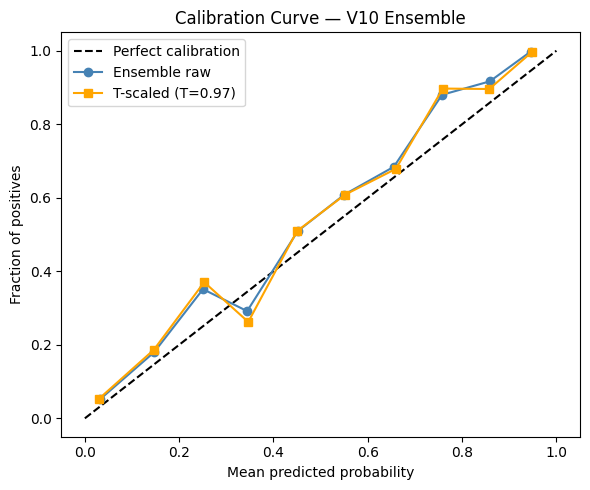

In [14]:

# ── Temperature Scaling — Post-Hoc Calibration ───────────────────────────────
#
# Duzeltmeler:
#   - Temperature daima pozitiftir: T = exp(log_temperature)
#   - T, son fold yerine tum OOF validation tahminleriyle fit edilir
#   - Final threshold test label'lariyla degil, OOF validation ile secilir
#   - Pozitif T monotonic oldugu icin AUC siralamasi ters donmez

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

class TemperatureScaler(nn.Module):
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor([init_temperature], dtype=torch.float32)))

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(min=0.05, max=20.0)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits_np, labels_np):
        logits_t = torch.tensor(logits_np, dtype=torch.float32)
        labels_t = torch.tensor(labels_np, dtype=torch.float32)
        opt = torch.optim.LBFGS([self.log_temperature], lr=0.05, max_iter=100, line_search_fn='strong_wolfe')

        def closure():
            opt.zero_grad()
            loss = F.binary_cross_entropy_with_logits(self.forward(logits_t), labels_t)
            loss.backward()
            return loss

        opt.step(closure)
        return float(self.temperature.item())

    def predict_proba(self, logits_np):
        logits_t = torch.tensor(logits_np, dtype=torch.float32)
        with torch.no_grad():
            return torch.sigmoid(self.forward(logits_t)).cpu().numpy()


# Raw 5-fold ensemble: average test probabilities across folds
ensemble_probs_raw = np.stack(fold_test_probs, axis=0).mean(axis=0)
oof_logits_raw     = probs_to_logits(oof_val_probs)
ens_logits_raw     = probs_to_logits(ensemble_probs_raw)

# OOF validation threshold for raw ensemble-style probabilities
raw_thr, raw_oof_f1 = find_best_threshold(oof_val_labels, oof_val_probs)
raw_ens_preds = (ensemble_probs_raw >= raw_thr).astype(int)
raw_ens_auc   = roc_auc_score(te_labels_np, ensemble_probs_raw)
raw_ens_f1    = f1_score(te_labels_np.astype(int), raw_ens_preds, average='macro')
raw_ens_prec  = precision_score(te_labels_np.astype(int), raw_ens_preds, pos_label=1, zero_division=0)
raw_ens_rec   = recall_score(te_labels_np.astype(int), raw_ens_preds, pos_label=1, zero_division=0)

# Fit T on OOF validation logits, then pick threshold on calibrated OOF validation probabilities
temp_scaler = TemperatureScaler(init_temperature=1.0)
T_fitted = temp_scaler.fit(oof_logits_raw, oof_val_labels)
oof_probs_calib = temp_scaler.predict_proba(oof_logits_raw)
ens_probs_calib = temp_scaler.predict_proba(ens_logits_raw)

ens_thr, oof_f1_calib = find_best_threshold(oof_val_labels, oof_probs_calib)
ens_preds = (ens_probs_calib >= ens_thr).astype(int)

ens_auc  = roc_auc_score(te_labels_np, ens_probs_calib)
ens_f1   = f1_score(te_labels_np.astype(int), ens_preds, average='macro')
ens_prec = precision_score(te_labels_np.astype(int), ens_preds, pos_label=1, zero_division=0)
ens_rec  = recall_score(te_labels_np.astype(int), ens_preds, pos_label=1, zero_division=0)

raw_ece = expected_calibration_error(te_labels_np, ensemble_probs_raw)
cal_ece = expected_calibration_error(te_labels_np, ens_probs_calib)
raw_brier = brier_score_loss(te_labels_np, ensemble_probs_raw)
cal_brier = brier_score_loss(te_labels_np, ens_probs_calib)

print(f'Temperature T = {T_fitted:.4f}  (fitted on OOF validation set)')
print(f'OOF threshold raw={raw_thr:.2f}  raw OOF F1={raw_oof_f1:.4f}')
print(f'OOF threshold calibrated={ens_thr:.2f}  calibrated OOF F1={oof_f1_calib:.4f}')

print('\nEnsemble raw — Test:')
print(f'  AUC={raw_ens_auc:.4f}  F1={raw_ens_f1:.4f}  Prec={raw_ens_prec:.4f}  Rec={raw_ens_rec:.4f}  thr={raw_thr:.2f}')
print(f'  Brier={raw_brier:.4f}  ECE={raw_ece:.4f}')

print(f'\nEnsemble calibrated (T={T_fitted:.3f}) — Test:')
print(f'  AUC={ens_auc:.4f}  F1={ens_f1:.4f}  Prec={ens_prec:.4f}  Rec={ens_rec:.4f}  thr={ens_thr:.2f}')
print(f'  Brier={cal_brier:.4f}  ECE={cal_ece:.4f}')

# Calibration curve comparison
fig, ax = plt.subplots(figsize=(6, 5))
frac_pos_raw, mean_pred_raw = calibration_curve(te_labels_np, ensemble_probs_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(te_labels_np, ens_probs_calib, n_bins=10)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', color='steelblue', label='Ensemble raw')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='orange', label=f'T-scaled (T={T_fitted:.2f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — V10 Ensemble')
ax.legend(); plt.tight_layout(); plt.show()


=== Fold-wise Val Results ===
 fold  vl_auc  vl_f1  vl_prec  vl_rec  threshold
    1  0.9618 0.8984   0.9146  0.9204     0.3700
    2  0.9632 0.9037   0.9388  0.9001     0.5200
    3  0.9637 0.9024   0.9209  0.9196     0.3100
    4  0.9679 0.9084   0.9246  0.9259     0.3900
    5  0.9621 0.9033   0.9413  0.8966     0.4100

=== Fold-wise Test Results ===
 fold  te_auc  te_f1  te_prec  te_rec  threshold
    1  0.9607 0.8958   0.9082  0.9240     0.3700
    2  0.9624 0.8976   0.9346  0.8939     0.5200
    3  0.9620 0.8896   0.9047  0.9169     0.3100
    4  0.9635 0.8959   0.9094  0.9224     0.3900
    5  0.9611 0.8926   0.9262  0.8947     0.4100

=== Mean ± Std (Test) ===
  AUC   : 0.9619 ± 0.0011
  F1    : 0.8943 ± 0.0032
  Prec  : 0.9166 ± 0.0130
  Rec   : 0.9104 ± 0.0149

=== Ensemble Raw Test (threshold from OOF val) ===
  AUC : 0.9685
  F1  : 0.9020
  Prec: 0.9200
  Rec : 0.9200
  thr : 0.39
  ECE : 0.0461

=== Ensemble Calibrated (T=0.966, threshold from OOF val) Test ===
  AUC : 0.9

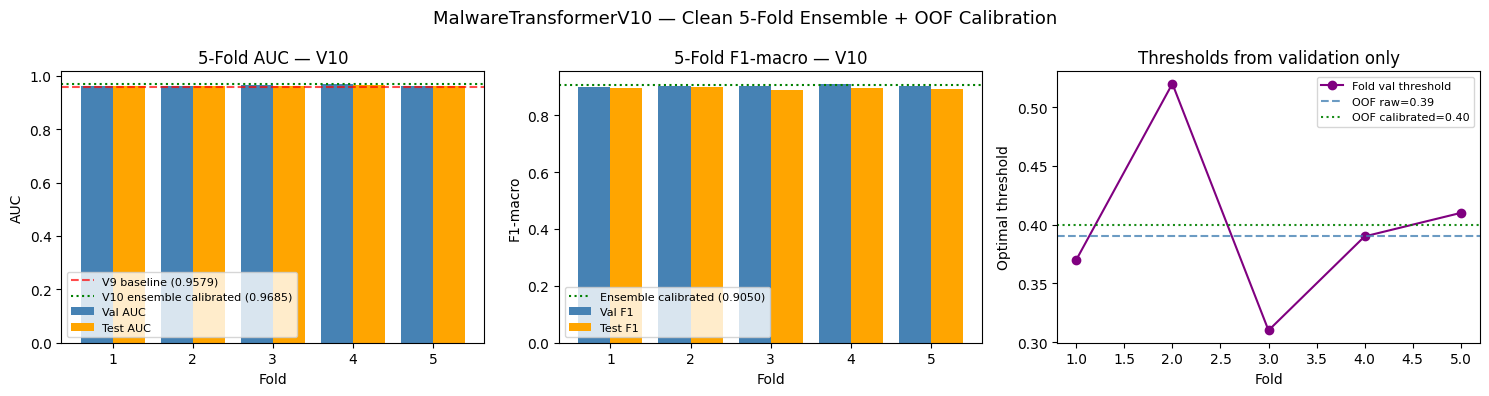

In [15]:

# ── v10 Results Summary ───────────────────────────────────────────────────────
df_folds = pd.DataFrame(fold_results)

print('=== Fold-wise Val Results ===')
print(df_folds[['fold','vl_auc','vl_f1','vl_prec','vl_rec','threshold']
              ].to_string(index=False, float_format='{:.4f}'.format))

print('\n=== Fold-wise Test Results ===')
print(df_folds[['fold','te_auc','te_f1','te_prec','te_rec','threshold']
              ].to_string(index=False, float_format='{:.4f}'.format))

print('\n=== Mean ± Std (Test) ===')
for col, label in [('te_auc','AUC'), ('te_f1','F1'), ('te_prec','Prec'), ('te_rec','Rec')]:
    m_v, s_v = df_folds[col].mean(), df_folds[col].std()
    print(f'  {label:6s}: {m_v:.4f} ± {s_v:.4f}')

print('\n=== Ensemble Raw Test (threshold from OOF val) ===')
print(f'  AUC : {raw_ens_auc:.4f}')
print(f'  F1  : {raw_ens_f1:.4f}')
print(f'  Prec: {raw_ens_prec:.4f}')
print(f'  Rec : {raw_ens_rec:.4f}')
print(f'  thr : {raw_thr:.2f}')
print(f'  ECE : {raw_ece:.4f}')

print(f'\n=== Ensemble Calibrated (T={T_fitted:.3f}, threshold from OOF val) Test ===')
print(f'  AUC : {ens_auc:.4f}')
print(f'  F1  : {ens_f1:.4f}')
print(f'  Prec: {ens_prec:.4f}')
print(f'  Rec : {ens_rec:.4f}')
print(f'  thr : {ens_thr:.2f}')
print(f'  ECE : {cal_ece:.4f}')

print('\n=== Version Comparison ===')
print(f'  v7  (single-split)          : AUC 0.9530')
print(f'  v9  (single-split, best ckpt): AUC {txf_auc:.4f}')
print(f'  v10 mean ± std (5-fold)     : AUC {df_folds["te_auc"].mean():.4f} ± {df_folds["te_auc"].std():.4f}')
print(f'  v10 ensemble raw            : AUC {raw_ens_auc:.4f}')
print(f'  v10 ensemble calibrated     : AUC {ens_auc:.4f}')

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df_folds['fold'] - 0.2, df_folds['vl_auc'], 0.4,
            color='steelblue', label='Val AUC')
axes[0].bar(df_folds['fold'] + 0.2, df_folds['te_auc'], 0.4,
            color='orange', label='Test AUC')
axes[0].axhline(txf_auc, linestyle='--', color='red', alpha=0.7,
                label=f'V9 baseline ({txf_auc:.4f})')
axes[0].axhline(ens_auc, linestyle=':', color='green',
                label=f'V10 ensemble calibrated ({ens_auc:.4f})')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('AUC')
axes[0].set_title('5-Fold AUC — V10'); axes[0].legend(fontsize=8)

axes[1].bar(df_folds['fold'] - 0.2, df_folds['vl_f1'], 0.4,
            color='steelblue', label='Val F1')
axes[1].bar(df_folds['fold'] + 0.2, df_folds['te_f1'], 0.4,
            color='orange', label='Test F1')
axes[1].axhline(ens_f1, linestyle=':', color='green',
                label=f'Ensemble calibrated ({ens_f1:.4f})')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-macro')
axes[1].set_title('5-Fold F1-macro — V10'); axes[1].legend(fontsize=8)

axes[2].plot(df_folds['fold'], df_folds['threshold'], 'o-', color='purple', label='Fold val threshold')
axes[2].axhline(raw_thr, linestyle='--', color='steelblue', alpha=0.8, label=f'OOF raw={raw_thr:.2f}')
axes[2].axhline(ens_thr, linestyle=':', color='green', alpha=0.9, label=f'OOF calibrated={ens_thr:.2f}')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('Optimal threshold')
axes[2].set_title('Thresholds from validation only'); axes[2].legend(fontsize=8)

plt.suptitle('MalwareTransformerV10 — Clean 5-Fold Ensemble + OOF Calibration', fontsize=13)
plt.tight_layout(); plt.show()
